# Normalization & Standardization
## Image Preprocessing Pipeline

This notebook demonstrates:
- Image resizing strategies
- Pixel normalization techniques
- Standardization methods
- Preprocessing pipeline setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import logging
import random
from collections import defaultdict
import json

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
sns.set_style('whitegrid')
random.seed(42)
np.random.seed(42)

print('Libraries loaded')

Libraries loaded


## 1. Load Sample Images for Analysis

In [2]:
dataset_root = Path('../dataset')
metadata_path = Path('../dataset/dataset_metadata.json')

with open(metadata_path, 'r') as f:
    metadata = json.load(f)

# Load sample images
sample_images = []
image_index = defaultdict(list)

for split in ['train', 'val', 'test']:
    split_path = dataset_root / split
    for class_folder in split_path.iterdir():
        if class_folder.is_dir():
            images = list(class_folder.glob('*.jpg')) + list(class_folder.glob('*.jpeg')) + \
                     list(class_folder.glob('*.png')) + list(class_folder.glob('*.JPG'))
            image_index[class_folder.name].extend(images)

# Get diverse sample
for images in image_index.values():
    if images:
        sample_images.append(random.choice(images))

sample_images = sample_images[:20]  # Use 20 samples
logger.info(f'Loaded {len(sample_images)} sample images')

INFO:__main__:Loaded 20 sample images


## 2. Define Preprocessing Functions

In [3]:
class ImagePreprocessor:
    """Standardized image preprocessing pipeline"""
    
    @staticmethod
    def resize_image(image, target_size=(256, 256), method='center_crop_resize'):
        """
        Resize image with different strategies:
        - 'simple': Direct resize (may distort aspect ratio)
        - 'center_crop_resize': Center crop then resize
        - 'letterbox': Maintain aspect ratio with padding
        """
        if method == 'simple':
            return image.resize(target_size, Image.Resampling.LANCZOS)
        
        elif method == 'center_crop_resize':
            # Center crop to square first
            w, h = image.size
            min_dim = min(w, h)
            left = (w - min_dim) // 2
            top = (h - min_dim) // 2
            right = left + min_dim
            bottom = top + min_dim
            
            cropped = image.crop((left, top, right, bottom))
            return cropped.resize(target_size, Image.Resampling.LANCZOS)
        
        elif method == 'letterbox':
            # Maintain aspect ratio with padding
            image.thumbnail(target_size, Image.Resampling.LANCZOS)
            new_img = Image.new('RGB', target_size, color=(128, 128, 128))
            offset = ((target_size[0] - image.size[0]) // 2,
                      (target_size[1] - image.size[1]) // 2)
            new_img.paste(image, offset)
            return new_img
    
    @staticmethod
    def normalize_pixels(image_array, method='standard'):
        """
        Normalize pixel values:
        - 'min_max': Scale to [0, 1]
        - 'standard': Standardize to mean=0, std=1
        - 'imagenet': ImageNet normalization
        """
        arr = image_array.astype(np.float32)
        
        if method == 'min_max':
            return arr / 255.0
        
        elif method == 'standard':
            return (arr - arr.mean()) / (arr.std() + 1e-7)
        
        elif method == 'imagenet':
            # ImageNet mean and std (RGB)
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            arr = arr / 255.0
            return (arr - mean) / std
    
    @staticmethod
    def preprocess(image_path, target_size=(256, 256), 
                   resize_method='center_crop_resize', 
                   normalize_method='imagenet'):
        """Complete preprocessing pipeline"""
        img = Image.open(image_path).convert('RGB')
        resized = ImagePreprocessor.resize_image(img, target_size, resize_method)
        arr = np.array(resized)
        normalized = ImagePreprocessor.normalize_pixels(arr, normalize_method)
        return normalized

logger.info('Preprocessor class defined')

INFO:__main__:Preprocessor class defined


## 3. Analyze Original vs Preprocessed Images

In [4]:
# Analyze original images
original_stats = []

for img_path in sample_images[:10]:
    img = Image.open(img_path).convert('RGB')
    arr = np.array(img)
    
    original_stats.append({
        'Method': 'Original',
        'Width': arr.shape[1],
        'Height': arr.shape[0],
        'Mean': arr.mean(),
        'Std': arr.std(),
        'Min': arr.min(),
        'Max': arr.max()
    })

df_original = pd.DataFrame(original_stats)
print("\n=== ORIGINAL IMAGES STATISTICS ===")
print(df_original.describe())


=== ORIGINAL IMAGES STATISTICS ===
           Width     Height        Mean        Std        Min         Max
count   10.00000   10.00000   10.000000  10.000000  10.000000   10.000000
mean   342.40000  342.40000  123.900445  50.537610   3.600000  243.500000
std     74.36128   74.36128   19.572691  13.831798   7.381659   17.212721
min    256.00000  256.00000   96.258952  30.172779   0.000000  205.000000
25%    256.00000  256.00000  111.396596  38.215258   0.000000  242.750000
50%    400.00000  400.00000  120.799268  51.813281   0.000000  251.000000
75%    400.00000  400.00000  139.452234  62.260770   2.500000  255.000000
max    400.00000  400.00000  151.111121  69.976803  23.000000  255.000000


In [5]:
# Test different preprocessing methods
target_size = (256, 256)
preprocessed_stats = {'min_max': [], 'standard': [], 'imagenet': []}

for img_path in sample_images[:10]:
    img = Image.open(img_path).convert('RGB')
    
    # Apply different methods
    for norm_method in ['min_max', 'standard', 'imagenet']:
        preprocessed = ImagePreprocessor.preprocess(
            img_path, 
            target_size=target_size,
            resize_method='center_crop_resize',
            normalize_method=norm_method
        )
        
        preprocessed_stats[norm_method].append({
            'Method': norm_method,
            'Width': preprocessed.shape[1],
            'Height': preprocessed.shape[0],
            'Mean': preprocessed.mean(),
            'Std': preprocessed.std(),
            'Min': preprocessed.min(),
            'Max': preprocessed.max()
        })

# Combine results
all_preprocessed = []
for method in ['min_max', 'standard', 'imagenet']:
    all_preprocessed.extend(preprocessed_stats[method])

df_preprocessed = pd.DataFrame(all_preprocessed)

print("\n=== PREPROCESSING METHODS COMPARISON ===")
for method in ['min_max', 'standard', 'imagenet']:
    print(f"\n{method.upper()}:")
    subset = df_preprocessed[df_preprocessed['Method'] == method]
    print(f"  Mean: {subset['Mean'].mean():.4f} ± {subset['Mean'].std():.4f}")
    print(f"  Std: {subset['Std'].mean():.4f} ± {subset['Std'].std():.4f}")
    print(f"  Range: [{subset['Min'].min():.4f}, {subset['Max'].max():.4f}]")


=== PREPROCESSING METHODS COMPARISON ===

MIN_MAX:
  Mean: 0.4859 ± 0.0768
  Std: 0.1977 ± 0.0542
  Range: [0.0000, 1.0000]

STANDARD:
  Mean: 0.0000 ± 0.0000
  Std: 1.0000 ± 0.0000
  Range: [-3.2769, 5.1744]

IMAGENET:
  Mean: 0.1644 ± 0.3398
  Std: 0.8814 ± 0.2333
  Range: [-2.1179, 2.6400]


## 4. Visual Comparison of Preprocessing Methods

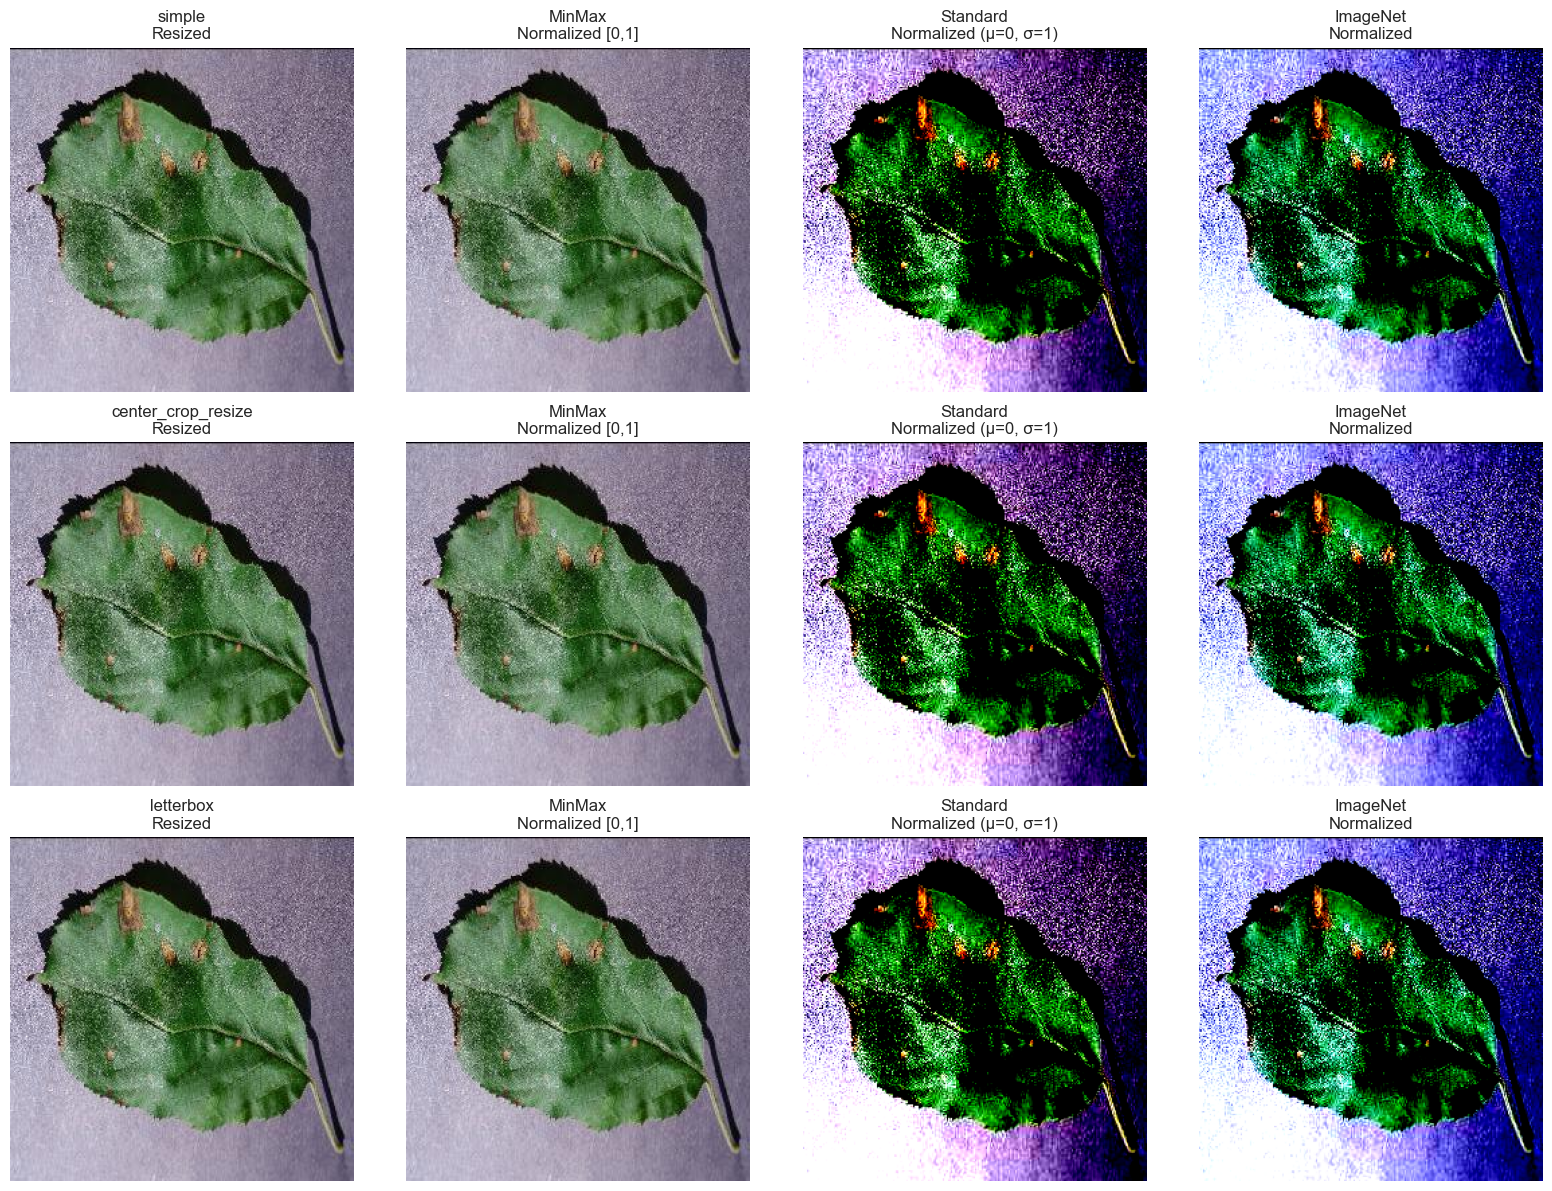

INFO:__main__:Preprocessing comparison visualization saved


In [6]:
# Show preprocessing pipeline visualization
sample_img_path = sample_images[0]
original = Image.open(sample_img_path).convert('RGB')

# Generate different preprocessing results
resize_methods = ['simple', 'center_crop_resize', 'letterbox']

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row, resize_method in enumerate(resize_methods):
    # Resized
    resized = ImagePreprocessor.resize_image(original, (256, 256), resize_method)
    axes[row, 0].imshow(resized)
    axes[row, 0].set_title(f'{resize_method}\nResized')
    axes[row, 0].axis('off')
    
    # MinMax normalized
    normalized_minmax = ImagePreprocessor.preprocess(
        sample_img_path, target_size=(256, 256),
        resize_method=resize_method, normalize_method='min_max'
    )
    axes[row, 1].imshow(normalized_minmax)
    axes[row, 1].set_title('MinMax\nNormalized [0,1]')
    axes[row, 1].axis('off')
    
    # Standard normalized
    normalized_std = ImagePreprocessor.preprocess(
        sample_img_path, target_size=(256, 256),
        resize_method=resize_method, normalize_method='standard'
    )
    # Clip for visualization
    axes[row, 2].imshow(np.clip(normalized_std, -2, 2))
    axes[row, 2].set_title('Standard\nNormalized (μ=0, σ=1)')
    axes[row, 2].axis('off')
    
    # ImageNet normalized
    normalized_imagenet = ImagePreprocessor.preprocess(
        sample_img_path, target_size=(256, 256),
        resize_method=resize_method, normalize_method='imagenet'
    )
    # Clip for visualization
    axes[row, 3].imshow(np.clip(normalized_imagenet, -1, 1))
    axes[row, 3].set_title('ImageNet\nNormalized')
    axes[row, 3].axis('off')

plt.tight_layout()
plt.savefig('../notebooks/figures/08_preprocessing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

logger.info('Preprocessing comparison visualization saved')

## 5. Statistical Comparison of Normalization Methods

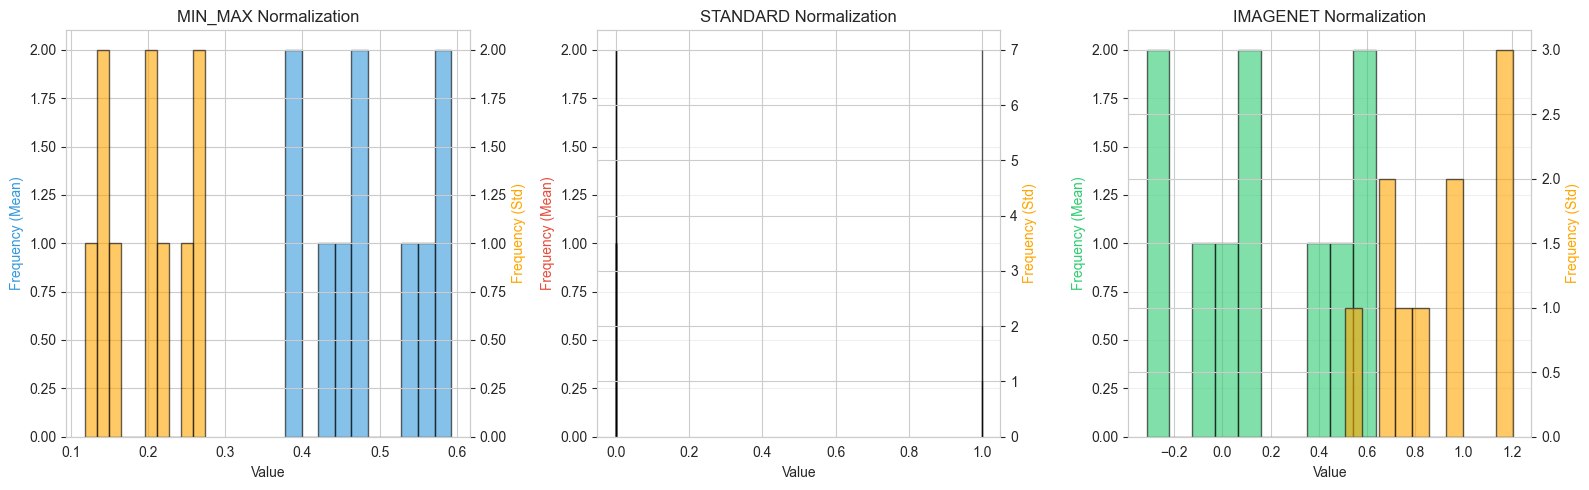

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

methods = ['min_max', 'standard', 'imagenet']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, (method, color) in enumerate(zip(methods, colors)):
    subset = df_preprocessed[df_preprocessed['Method'] == method]
    
    ax = axes[idx]
    
    # Create box plot data
    means = subset['Mean'].values
    stds = subset['Std'].values
    
    ax.hist(means, bins=10, alpha=0.6, label='Mean', color=color, edgecolor='black')
    ax_twin = ax.twinx()
    ax_twin.hist(stds, bins=10, alpha=0.6, label='Std', color='orange', edgecolor='black')
    
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency (Mean)', color=color)
    ax_twin.set_ylabel('Frequency (Std)', color='orange')
    ax.set_title(f'{method.upper()} Normalization')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/09_normalization_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Recommended Preprocessing Pipeline

In [8]:
print("\n" + "="*70)
print("RECOMMENDED PREPROCESSING PIPELINE FOR PRODUCTION")
print("="*70)

print("""
## Recommended Configuration:

### Resizing Strategy: CENTER_CROP_RESIZE
- Preserves important central features of crop/disease
- Maintains aspect ratio consistency
- Removes extreme/padded regions
- Target size: 256x256 or 224x224

### Normalization: ImageNet Normalization
- Uses mean=[0.485, 0.456, 0.406]
- Uses std=[0.229, 0.224, 0.225]
- Standard for pretrained models (ResNet, EfficientNet, etc.)
- Enables transfer learning from ImageNet-pretrained weights

### Implementation Code:
```python
from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize((256, 256), 
                       interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
```

### Alternative for Custom Training:
```python
transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[img_mean_per_channel],
        std=[img_std_per_channel]
    )
])
```
""")

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)
print(f"\nOriginal Images:")
print(f"  Size range: {df_original['Width'].min()}-{df_original['Width'].max()}x{df_original['Height'].min()}-{df_original['Height'].max()}")
print(f"  Pixel range: [{df_original['Min'].min():.1f}, {df_original['Max'].max():.1f}]")
print(f"  Mean brightness: {df_original['Mean'].mean():.1f} ± {df_original['Mean'].std():.1f}")

print(f"\nAfter Preprocessing (256x256, ImageNet norm):")
imagenet_subset = df_preprocessed[df_preprocessed['Method'] == 'imagenet']
print(f"  Size: 256x256 (fixed)")
print(f"  Pixel range: [{imagenet_subset['Min'].min():.3f}, {imagenet_subset['Max'].max():.3f}]")
print(f"  Mean: {imagenet_subset['Mean'].mean():.4f} (target: 0.0)")
print(f"  Std: {imagenet_subset['Std'].mean():.4f} (target: 1.0)")


RECOMMENDED PREPROCESSING PIPELINE FOR PRODUCTION

## Recommended Configuration:

### Resizing Strategy: CENTER_CROP_RESIZE
- Preserves important central features of crop/disease
- Maintains aspect ratio consistency
- Removes extreme/padded regions
- Target size: 256x256 or 224x224

### Normalization: ImageNet Normalization
- Uses mean=[0.485, 0.456, 0.406]
- Uses std=[0.229, 0.224, 0.225]
- Standard for pretrained models (ResNet, EfficientNet, etc.)
- Enables transfer learning from ImageNet-pretrained weights

### Implementation Code:
```python
from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize((256, 256), 
                       interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
```

### Alternative for Custom Training:
```python
transforms.Compose([
    transforms.Resize(